In [10]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

import dask

from dask.distributed import Client
import multiprocessing

ncpu = multiprocessing.cpu_count()
threads = 8
nworker = ncpu // threads
print(
    f"Number of CPUs: {ncpu}, number of threads: {threads}, number of workers: {nworker}"
)
client = Client(
    processes=True, threads_per_worker=threads, n_workers=nworker, memory_limit="100GB"
)
client 

# calculation
# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
from dask.utils import format_bytes
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data

# dask
import dask # Distributed data libary
import dask.distributed
import multiprocessing
from subprocess import run, PIPE
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})

2025-09-29 17:19:57,154 - distributed.scheduler - WARNING - Failed to format dashboard link, unknown value: 'JUPYTERHUB_SERVICE_PREFIX'


Number of CPUs: 256, number of threads: 8, number of workers: 32


In [2]:
import sys
sys.path.append('/home/m/m300948/ICON_AMZDEF')
import Tools

2025-09-29 17:08:03,673 - distributed.scheduler - WARNING - Failed to format dashboard link, unknown value: 'JUPYTERHUB_SERVICE_PREFIX'


Number of CPUs: 256, number of threads: 8, number of workers: 32


In [11]:
def mask_cal(dset):
    ##This function calculate the land_sea mask according to the resolution of the data##
    ###negative values is ocean, positive values is land
    filemask = '/work/mh0731/from_Mistral/mh0731/m300876/land_sea_mask/GPM_IMERG_LandSeaMask.2.nc4'
    dsetmask = xr.open_dataset(filemask)
    lsmask01 = dsetmask.landseamask.where(
        dsetmask.landseamask<100).interp(lon=dset.lon.values,lat=dset.lat.values,method='linear') *0 +2
    lsmask01 = lsmask01.where(lsmask01==2,-2)
    return lsmask01

In [12]:
import healpy as hp
def get_amazon_index(nside=12**2, nest=True):
    amazon = xr.open_dataset(
        "/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc"
    ).stack(cell=("latitude", "longitude"))
    
    is_amazon = amazon.where(amazon.AMAZON_BIOMES == 0, drop=True)
    
    return np.unique(hp.ang2pix(nside, is_amazon.longitude.values, is_amazon.latitude.values, nest=nest, lonlat=True)).astype(int)

In [13]:
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES

In [14]:
# BR_Sa1 (lat: -2.8567, lon: -54.9589, height: 57.6)
flux_data = pd.read_csv('/work/mh0731/m300793/data/Fluxnet2015/FLX_BR-Sa1_FLUXNET2015_FULLSET_HR_2002-2011_1-4.csv', sep=',', header=0, index_col=0, parse_dates=True)

In [15]:
# BR_Sa3 (lat: -3.0180, lon: -54.9714, height: 64)
flux_data_sa3 = pd.read_csv('/work/mh0731/m300793/data/Fluxnet2015/FLX_BR-Sa3_FLUXNET2015_FULLSET_HH_2000-2004_1-4.csv', sep=',', header=0, index_col=0, parse_dates=True)

## Temperature

_1. fluxnet_

In [24]:
# load variables (hourly)
brazil_sa1_t2m = flux_data['TA_F_MDS']
brazil_sa3_t2m = flux_data_sa3['TA_F_MDS']

In [25]:
br_sa1_t2m = brazil_sa1_t2m.to_xarray()
br_sa3_t2m = brazil_sa3_t2m.to_xarray()

In [26]:
br_sa1_t2m = br_sa1_t2m.where(br_sa1_t2m != -9999.0, np.nan)
br_sa3_t2m = br_sa3_t2m.where(br_sa3_t2m != -9999.0, np.nan)

In [27]:
br_sa1_t2m = br_sa1_t2m.rename({'TIMESTAMP_START':'time'})
br_sa3_t2m = br_sa3_t2m.rename({'TIMESTAMP_START':'time'})

In [28]:
br_sa1_t2m_hourly = br_sa1_t2m.groupby('time.time').mean('time',skipna=True)
br_sa3_t2m_hourly = br_sa3_t2m.groupby('time.time').mean('time',skipna=True)

In [29]:
br_t2m_hourly_mean = (br_sa1_t2m_hourly + br_sa3_t2m_hourly)/2

In [30]:
br_t2m_hourly_mean

<xarray.DataArray 'TA_F_MDS' (time: 24)> Size: 192B
array([24.88480428, 24.61946925, 24.3876875 , 24.16280827, 23.9595537 ,
       23.62766348, 23.67710563, 24.33116613, 25.2989291 , 26.30843004,
       27.25710629, 27.90127778, 28.33543131, 28.56655116, 28.48148034,
       28.27532533, 27.88841037, 27.29632318, 26.56300987, 26.22701173,
       25.92843085, 25.66485599, 25.39670283, 25.15304741])
Coordinates:
  * time     (time) object 192B 00:00:00 01:00:00 02:00:00 ... 22:00:00 23:00:00

_2. Load icon data_

In [14]:
#Define a global pattern to find the files
glob_pattern_3d1 = 'ctl_houly_tas_202'

## Define the paths
data_path_2mt = Path('/scratch/m/m300948/test_04/2mt')

## Collect all file names with pathlib's rglob and list compression  
file_icon_2mt = sorted([str(f) for f in data_path_2mt.rglob(f'*{glob_pattern_3d1}*.nc')])[:]

In [15]:
times = ['2020-02-01','2022-12-31']

t2m_ctl_land = Tools.time_mean_model(file_icon_2mt,times,'1H','tas',[-30,13],[-82,-30],'land')

_1) local site_

In [32]:
t2m_ctl_sa1 = t2m_ctl_land.interp(lat=-2.8567, lon=-54.9589, method='nearest')
t2m_ctl_sa3 = t2m_ctl_land.interp(lat=-3.0180, lon=-54.9714, method='nearest')

_2) Average over the region with same degrees away from the point_

In [16]:
# fluxnet (lat: -2.8567, lon: -54.9589)
dist_degree = 0.1 # 0.1 degree = 11.1 km

t2m_ctl_sa1 = t2m_ctl_land.sel(lat=slice(-2.8567-dist_degree,-2.8567+dist_degree), lon=slice(-54.9589-dist_degree,-54.9589+dist_degree)).mean(('lat','lon'))

In [17]:
# ABRACOS (lat:-10.05, lon:-61.55)
dist_degree = 0.1 # 0.1 degree = 11.1 km

t2m_ctl_sa3 = t2m_ctl_land.sel(lat=slice(-10.05-dist_degree,-10.05+dist_degree), lon=slice(-61.55-dist_degree,-61.55+dist_degree)).mean(('lat','lon'))

In [33]:
t2m_hourly_ctl_sa1 = t2m_ctl_sa1.groupby('time.time').mean('time',skipna=True)
t2m_hourly_ctl_sa3 = t2m_ctl_sa3.groupby('time.time').mean('time',skipna=True)

In [34]:
ctl_t2m_hourly_mean = (t2m_hourly_ctl_sa1.isel(height_2=0)+t2m_hourly_ctl_sa3.isel(height_2=0))/2

In [35]:
t2m_hourly_ctl_celsius = ctl_t2m_hourly_mean - 273.15

_plotting_

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

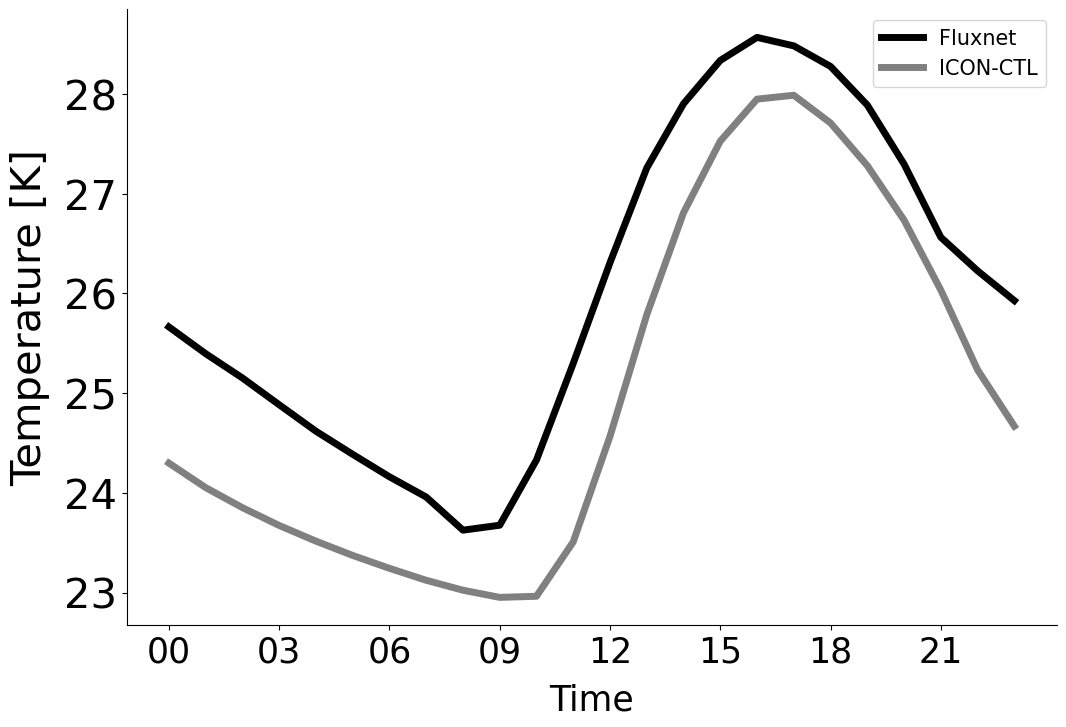

In [36]:
fig, ax = plt.subplots(figsize=(12,8))
# get color from BrBG
shift = 3
s_roll = br_t2m_hourly_mean.copy()
s_roll.values[:] = np.roll(s_roll.values, shift) 

a = [0,3,6,9,12,15,18,21]
plt.plot(s_roll, label='Fluxnet',c='black',linewidth=5)
plt.plot(t2m_hourly_ctl_celsius, label='ICON-CTL', c='grey',linewidth=5)
#plt.errorbar(a, s_roll.values[::3], br_t2m_std.sel(height_2=2).values[::3],  marker='o', markersize='8', linewidth=3, c='black')
#plt.errorbar(diurnal_ts_std_ngc2_mask['time'].dt.hour, tas_ctl_savg_diurnal[::3], std_diurnal_cycle.values, linestyle='', marker='o', markersize='8', linewidth=3, c='black')

#plt.errorbar(a, tas_ctl_diurnal[::3], std_diurnal_cycle, linestyle='', marker='o', markersize='8', linewidth=3, c='black')

plt.xticks(fontsize=30)
plt.yticks(fontsize=30,family='Arial')

ax.set_ylabel('Temperature [K]',fontsize=30, labelpad = 10,family='Arial')
ax.set_xlabel('Time',fontsize=25, labelpad = 10)
#plt.xlabel('Difference PR [mm/day]',fontsize=25, labelpad = 20)
plt.xticks([0,3,6,9,12,15,18,21],['00','03','06','09','12','15','18','21'],fontsize=25,family='Arial')

ax.spines[['right', 'top']].set_visible(False)
plt.legend(fontsize=15)

### Max, Min temperature

_1. Fluxnet_

In [37]:
br_sa1_t2m_max = br_sa1_t2m.resample(time='1D').max(dim='time') 
br_sa3_t2m_max = br_sa3_t2m.resample(time='1D').max(dim='time')

In [38]:
xarray_names = ['br_sa1_t2m_max','br_sa3_t2m_max']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [24]:
br_sa1_t2m_min = br_sa1_t2m.resample(time='1D').min(dim='time') 
br_sa3_t2m_min = br_sa3_t2m.resample(time='1D').min(dim='time')

In [25]:
xarray_names = ['br_sa1_t2m_min','br_sa3_t2m_min']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [26]:
xarray_names = ['br_sa1_t2m','br_sa3_t2m']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

_2. ICON_

In [27]:
t2m_ctl_max = t2m_ctl_sa1.resample(time='1D').max(dim='time') 

In [28]:
xarray_names = ['t2m_ctl_max']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [29]:
t2m_ctl_min = t2m_ctl_sa1.resample(time='1D').min(dim='time') 

In [30]:
xarray_names = ['t2m_ctl_min']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [31]:
xarray_names = ['t2m_ctl_sa1']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

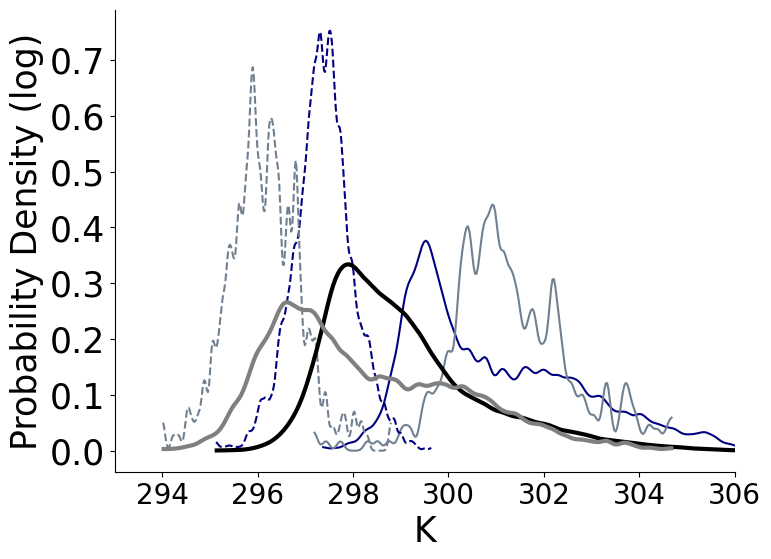

In [33]:
from scipy.ndimage import gaussian_filter1d

# Normalize the PDF
pdf_ctl_max, bins_ctl_max = np.histogram(br_sa1_t2m_max_f+273.15, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_max, bins_def_max = np.histogram(t2m_ctl_max_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_ctl_min, bins_ctl_min = np.histogram(br_sa1_t2m_min_f+273.15, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_min, bins_def_min = np.histogram(t2m_ctl_min_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_ctl_mean, bins_ctl_mean = np.histogram(br_sa1_t2m_f+273.15, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_mean, bins_def_mean = np.histogram(t2m_ctl_sa1_f, bins=250, density=True)  # Adjust the number of bins as needed

# Calculate the bin centers
bin_centers_ctl_max = (bins_ctl_max[:-1] + bins_ctl_max[1:]) * 0.5
bin_centers_def_max = (bins_def_max[:-1] + bins_def_max[1:]) * 0.5
bin_centers_ctl_min = (bins_ctl_min[:-1] + bins_ctl_min[1:]) * 0.5
bin_centers_def_min = (bins_def_min[:-1] + bins_def_min[1:]) * 0.5
bin_centers_ctl_mean = (bins_ctl_mean[:-1] + bins_ctl_mean[1:]) * 0.5
bin_centers_def_mean = (bins_def_mean[:-1] + bins_def_mean[1:]) * 0.5

# smooth
smooth_pdf_ctl_max = gaussian_filter1d(pdf_ctl_max, sigma=2.5)
smooth_pdf_def_max = gaussian_filter1d(pdf_def_max, sigma=2.5)
smooth_pdf_ctl_min = gaussian_filter1d(pdf_ctl_min, sigma=2.5)
smooth_pdf_def_min = gaussian_filter1d(pdf_def_min, sigma=2.5)
smooth_pdf_ctl_mean = gaussian_filter1d(pdf_ctl_mean, sigma=2.5)
smooth_pdf_def_mean = gaussian_filter1d(pdf_def_mean, sigma=2.5)

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))
plt.plot(bin_centers_ctl_max, smooth_pdf_ctl_max, label='CTL_max', color='navy', linewidth=1.5)
plt.plot(bin_centers_def_max, smooth_pdf_def_max, label='DEF_max', color='slategrey', linewidth=1.5)
plt.plot(bin_centers_ctl_min, smooth_pdf_ctl_min, label='CTL_min', color='navy', linewidth=1.5, ls='--')
plt.plot(bin_centers_def_min, smooth_pdf_def_min, label='DEF_min', color='slategrey', linewidth=1.5, ls='--')
plt.plot(bin_centers_ctl_mean, smooth_pdf_ctl_mean, label='CTL_mean', color='black', linewidth=3)
plt.plot(bin_centers_def_mean, smooth_pdf_def_mean, label='DEF_,mean', color='grey', linewidth=3)

# Set labels and title
plt.xlabel('K', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
#plt.yscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=25)
#plt.xscale('log')
#
plt.xlim(293, 306)
# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
#plt.legend(fontsize=15)

# Display the plot
plt.show()

## Wind

_1. fluxnet_

In [8]:
# load variables (hourly)
brazil_sa1_ws = flux_data['WS']
brazil_sa3_ws = flux_data_sa3['WS']

In [9]:
br_sa1_ws = brazil_sa1_ws.to_xarray()
br_sa3_ws = brazil_sa3_ws.to_xarray()

In [10]:
br_sa1_ws = br_sa1_ws.where(br_sa1_ws != -9999.0, np.nan)
br_sa3_ws = br_sa3_ws.where(br_sa3_ws != -9999.0, np.nan)

In [11]:
br_sa1_ws = br_sa1_ws.rename({'TIMESTAMP_START':'time'})
br_sa3_ws = br_sa3_ws.rename({'TIMESTAMP_START':'time'})

In [12]:
br_sa1_ws_1d = br_sa1_ws.resample(time='1D').mean(dim=('time'),skipna=True)
br_sa3_ws_1d = br_sa3_ws.resample(time='1D').mean(dim=('time'),skipna=True)

_wind direction_

In [13]:
# load variables (hourly)
brazil_sa1_wd = flux_data['WD']
brazil_sa3_wd = flux_data_sa3['WD']

In [14]:
br_sa1_wd = brazil_sa1_wd.to_xarray()
br_sa3_wd = brazil_sa3_wd.to_xarray()

In [15]:
br_sa1_wd = br_sa1_wd.where(br_sa1_wd != -9999.0, np.nan)
br_sa3_wd = br_sa3_wd.where(br_sa3_wd != -9999.0, np.nan)

In [16]:
br_sa1_wd = br_sa1_wd.rename({'TIMESTAMP_START':'time'})
br_sa3_wd = br_sa3_wd.rename({'TIMESTAMP_START':'time'})

In [17]:
br_sa1_wd_1d = br_sa1_wd.resample(time='1D').mean(dim=('time'),skipna=True)
br_sa3_wd_1d = br_sa3_wd.resample(time='1D').mean(dim=('time'),skipna=True)

### 2. Load icon data

_my simulation: pressure levels_

In [22]:
#Define a global pattern to find the files
glob_pattern_uas = 'ctl_hourly_uas_2020'
glob_pattern_vas = 'ctl_hourly_vas_2020'

## Define the paths
data_path_wind = Path('/scratch/m/m300948/test_04/surface_wind')

## Collect all file names with pathlib's rglob and list compression  
file_icon_uas = sorted([str(f) for f in data_path_wind.rglob(f'*{glob_pattern_uas}*.nc')])[:]
file_icon_vas = sorted([str(f) for f in data_path_wind.rglob(f'*{glob_pattern_vas}*.nc')])[:]

In [ ]:
times = ['2020-01-20','2020-12-31']

uas_ctl_land = Tools.time_mean_model(file_icon_uas,times,'1D','uas',[-30,13],[-82,-30],'land')
vas_ctl_land = Tools.time_mean_model(file_icon_vas,times,'1D','vas',[-30,13],[-82,-30],'land')

In [ ]:
uas_ctl_sa1 = uas_ctl_land.interp(lat=-2.8567, lon=-54.9589, method='nearest').isel(height=0)
vas_ctl_sa1 = vas_ctl_land.interp(lat=-2.8567, lon=-54.9589, method='nearest').isel(height=0)

uas_ctl_sa3 = uas_ctl_land.interp(lat=-3.0180, lon=-54.9714, method='nearest').isel(height=0)
vas_ctl_sa3 = vas_ctl_land.interp(lat=-3.0180, lon=-54.9714, method='nearest').isel(height=0)

In [ ]:
wind_ctl_sa1 = np.hypot(uas_ctl_sa1, vas_ctl_sa1)

In [ ]:
wind_ctl_sa3 = np.hypot(uas_ctl_sa3, vas_ctl_sa3)

In [ ]:
wind_ctl_sa1_edit = wind_ctl_sa1.where(wind_ctl_sa1<=10, 0)

In [ ]:
wind_ctl_sa3_edit = wind_ctl_sa3.where(wind_ctl_sa3<=10, 0)

_AMIP NGC simulation_

In [18]:
# ICON CTL (5km)
import intake
import easygems.healpix as egh
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
data_ctl  = cat['ICON.C5.AMIP_CNTL'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1997 (19 years) original: zoom8

In [19]:
is_amazon = get_amazon_index(nside=egh.get_nside(data_ctl))
dx_ctl_amz = data_ctl.isel(cell=is_amazon).sel(time=slice("1980", "1994"))  # 1979-1997

In [53]:
data_ctl

<xarray.Dataset> Size: 8TB
Dimensions:             (cell: 786432, time: 6756, level_full: 26,
                         level_half: 26)
Coordinates:
  * time                (time) datetime64[ns] 54kB 1979-01-02 ... 1997-07-01
  * level_full          (level_full) float64 208B 14.0 21.0 25.0 ... 89.0 90.0
  * level_half          (level_half) float64 208B 14.0 21.0 25.0 ... 89.0 90.0
    crs                 int64 8B 0
  * cell                (cell) int64 6MB 0 1 2 3 ... 786428 786429 786430 786431
    lat                 (cell) float64 6MB 0.1492 0.2984 ... -0.2984 -0.1492
    lon                 (cell) float64 6MB 45.0 45.18 44.82 ... 314.8 315.0
Data variables: (12/47)
    cell_elevation      (cell) float64 6MB dask.array<chunksize=(786432,), meta=np.ndarray>
    cell_sea_land_mask  (cell) int32 3MB dask.array<chunksize=(786432,), meta=np.ndarray>
    clivi               (time, cell) float32 21GB dask.array<chunksize=(364, 81920), meta=np.ndarray>
    cllvi               (time, cell) float32 21GB dask.array<chunksize=(364, 81920), meta=np.ndarray>
    hus2m               (time, cell) float32 21GB dask.array<chunksize=(364, 81920), meta=np.ndarray>
    hfls                (time, cell) float32 21GB dask.array<chunksize=(364, 81920), meta=np.ndarray>
    ...                  ...
    ta                  (time, level_full, cell) float32 553GB dask.array<chunksize=(64, 8, 32768), meta=np.ndarray>
    pfull               (time, level_full, cell) float32 553GB dask.array<chunksize=(64, 8, 32768), meta=np.ndarray>
    phalf               (time, level_half, cell) float32 553GB dask.array<chunksize=(64, 8, 32768), meta=np.ndarray>
    zg                  (level_full, cell) float32 82MB dask.array<chunksize=(26, 786432), meta=np.ndarray>
    zghalf              (level_half, cell) float32 82MB dask.array<chunksize=(26, 786432), meta=np.ndarray>
    dzghalf             (level_full, cell) float32 82MB dask.array<chunksize=(26, 786432), meta=np.ndarray>
Attributes:
    history:  Wed May 15 09:39:51 2024: ncatted -O -a ,global,d,, independent...
    NCO:      netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, C...

In [20]:
# BR-SA1
tlat = -2.8567
tlon = (-54.9589 + 360) % 360

# Compute distance
dist = np.sqrt((dx_ctl_amz.lat - tlat)**2 + (dx_ctl_amz.lon - tlon)**2)

# Get nearest cell label
nearest_cell = dist.idxmin(dim="cell")

# Select value
zg_br1 = dx_ctl_amz.zg.sel(cell=nearest_cell)

In [21]:
zg_br1.values

array([45991.234  , 34774.66   , 29444.174  , 24851.475  , 22864.389  ,
       19538.84   , 17523.498  , 15843.214  , 13617.206  , 11618.269  ,
       10019.886  ,  8821.859  ,  6827.6016 ,  5239.9473 ,  3795.4224 ,
        2858.5046 ,  2303.633  ,  1804.8875 ,  1362.9354 ,  1163.6051 ,
         809.34924,   655.0817 ,   516.6675 ,   290.2637 ,   139.6932 ,
         100.40077], dtype=float32)

In [22]:
ua_br1 = dx_ctl_amz.ua.sel(cell=nearest_cell)
va_br1 = dx_ctl_amz.va.sel(cell=nearest_cell)

In [52]:
(-54.9714 + 360) % 360

305.0286

In [23]:
# BR-SA3
tlat = -3.0180
tlon = (-54.9714 + 360) % 360

# Compute distance
dist = np.sqrt((dx_ctl_amz.lat - tlat)**2 + (dx_ctl_amz.lon - tlon)**2)

# Get nearest cell label
nearest_cell = dist.idxmin(dim="cell")

# Select value
zg_br3 = dx_ctl_amz.zg.sel(cell=nearest_cell)

In [24]:
zg_br3.values

array([45991.234  , 34774.66   , 29444.174  , 24851.475  , 22864.39   ,
       19538.854  , 17523.53   , 15843.2705 , 13617.335  , 11618.525  ,
       10020.303  ,  8822.428  ,  6828.381  ,  5240.5615 ,  3795.0425 ,
        2856.5964 ,  2300.3203 ,  1799.9199 ,  1356.1636 ,  1155.9167 ,
         799.89636,   644.82104,   505.67465,   278.1021 ,   126.81616,
          87.3837 ], dtype=float32)

In [25]:
ua_br3 = dx_ctl_amz.ua.sel(cell=nearest_cell)
va_br3 = dx_ctl_amz.va.sel(cell=nearest_cell)

In [26]:
wind_ctl_sa1 = np.hypot(ua_br1.isel(level_half=0), va_br1.isel(level_half=0))

In [27]:
wind_ctl_sa3 = np.hypot(ua_br3.isel(level_half=0), va_br3.isel(level_half=0))

In [28]:
wind_ctl_sa1_edit = wind_ctl_sa1.where(wind_ctl_sa1<=10, 0)

In [29]:
wind_ctl_sa3_edit = wind_ctl_sa3.where(wind_ctl_sa3<=10, 0)

_PDF_

In [30]:
xarray_names = ['br_sa1_ws_1d','br_sa3_ws_1d']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [31]:
xarray_names = ['wind_ctl_sa1','wind_ctl_sa3']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

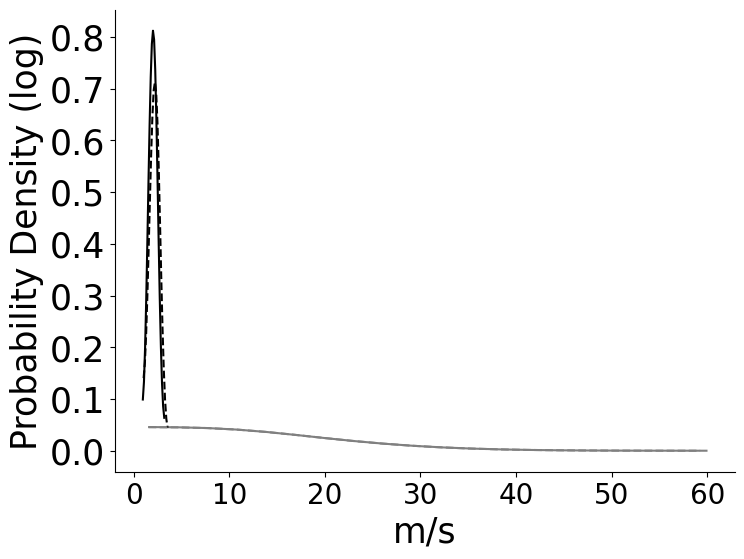

In [32]:
from scipy.ndimage import gaussian_filter1d

# Normalize the PDF
pdf_ctl_max, bins_ctl_max = np.histogram(br_sa1_ws_1d_f, bins=20, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_max, bins_def_max = np.histogram(wind_ctl_sa1_f, bins=20, density=True)  # Adjust the number of bins as needed
pdf_ctl_min, bins_ctl_min = np.histogram(br_sa3_ws_1d_f, bins=20, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_min, bins_def_min = np.histogram(wind_ctl_sa3_f, bins=20, density=True)  # Adjust the number of bins as needed
#pdf_ctl_mean, bins_ctl_mean = np.histogram(br_sa1_t2m_f+273.15, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
#pdf_def_mean, bins_def_mean = np.histogram(t2m_ctl_f, bins=250, density=True)  # Adjust the number of bins as needed

# Calculate the bin centers
bin_centers_ctl_max = (bins_ctl_max[:-1] + bins_ctl_max[1:]) * 0.5
bin_centers_def_max = (bins_def_max[:-1] + bins_def_max[1:]) * 0.5
bin_centers_ctl_min = (bins_ctl_min[:-1] + bins_ctl_min[1:]) * 0.5
bin_centers_def_min = (bins_def_min[:-1] + bins_def_min[1:]) * 0.5
#bin_centers_ctl_mean = (bins_ctl_mean[:-1] + bins_ctl_mean[1:]) * 0.5
#bin_centers_def_mean = (bins_def_mean[:-1] + bins_def_mean[1:]) * 0.5

# smooth
smooth_pdf_ctl_max = gaussian_filter1d(pdf_ctl_max, sigma=2.5)
smooth_pdf_def_max = gaussian_filter1d(pdf_def_max, sigma=2.5)
smooth_pdf_ctl_min = gaussian_filter1d(pdf_ctl_min, sigma=2.5)
smooth_pdf_def_min = gaussian_filter1d(pdf_def_min, sigma=2.5)
#smooth_pdf_ctl_mean = gaussian_filter1d(pdf_ctl_mean, sigma=2.5)
#smooth_pdf_def_mean = gaussian_filter1d(pdf_def_mean, sigma=2.5)

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))
plt.plot(bin_centers_ctl_max, smooth_pdf_ctl_max, label='Sa1_FLX', color='Black', linewidth=1.5)
plt.plot(bin_centers_def_max, smooth_pdf_def_max, label='Sa1_ICON', color='gray', linewidth=1.5)
plt.plot(bin_centers_ctl_min, smooth_pdf_ctl_min, label='Sa3_FLX', color='Black', linewidth=1.5, ls='--')
plt.plot(bin_centers_def_min, smooth_pdf_def_min, label='Sa3_ICON', color='gray', linewidth=1.5, ls='--')
#plt.plot(bin_centers_ctl_mean, smooth_pdf_ctl_mean, label='CTL_mean', color='black', linewidth=3)
#plt.plot(bin_centers_def_mean, smooth_pdf_def_mean, label='DEF_,mean', color='grey', linewidth=3)

# Set labels and title
plt.xlabel('m/s', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
#plt.yscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=25)
#plt.xscale('log')
#
#plt.xlim(293, 306)
# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
#plt.legend(fontsize=15)

# Display the plot
plt.show()

### Wind rose

In [33]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def uv_to_ws_wd(u, v):
    ws = np.hypot(u, v)
    wd = (np.degrees(np.arctan2(-u, -v)) + 360.0) % 360.0  # FROM which it blows
    return ws, wd

def wind_rose_counts(ws, wd, speed_bins=None, n_dir_sectors=12):
    if speed_bins is None:
        speed_bins = [0, 2, 4, 6, 8, 10, np.inf]
    ws = np.asarray(ws, float); wd = np.asarray(wd, float)
    mask = np.isfinite(ws) & np.isfinite(wd)
    ws, wd = ws[mask], wd[mask]

    dir_edges = np.linspace(0, 360, n_dir_sectors + 1)
    dir_idx = np.digitize(wd % 360, dir_edges, right=False) - 1
    dir_idx[dir_idx == n_dir_sectors] = 0

    speed_bins = np.asarray(speed_bins, float)
    sp_idx = np.digitize(ws, speed_bins, right=True) - 1
    sp_idx = np.clip(sp_idx, 0, len(speed_bins) - 2)

    counts = np.zeros((len(speed_bins) - 1, n_dir_sectors), dtype=int)
    for i_s, i_d in zip(sp_idx, dir_idx):
        counts[i_s, i_d] += 1

    centers_deg = (dir_edges[:-1] + dir_edges[1:]) / 2.0
    centers_rad = np.deg2rad(centers_deg)
    return centers_rad, counts, speed_bins

def plot_wind_rose_monthly(ws_da, wd_da, title="", speed_bins=None, n_dir_sectors=12, normalize="percent", min_count=5):
    # Align & sort
    ws_da, wd_da = xr.align(ws_da, wd_da, join="inner")
    ds = xr.Dataset({"ws": ws_da, "wd": wd_da}).sortby("time")

    fig, axes = plt.subplots(3, 4, subplot_kw={"projection": "polar"}, figsize=(14, 10), constrained_layout=True)
    axes = axes.ravel()

    if speed_bins is None:
        speed_bins = [0, 2, 4, 6, 8, 10, np.inf]
    bin_labels = [f"{speed_bins[i]}–{speed_bins[i+1]} m/s" if np.isfinite(speed_bins[i+1]) else f">{speed_bins[i]} m/s"
                  for i in range(len(speed_bins)-1)]

    legend_colors = None  # we’ll capture actual colors from the first non-empty month
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

    for m in range(1, 13):
        ax = axes[m-1]
        sub = ds.where(ds.time.dt.month == m, drop=True)

        if sub.time.size < min_count:
            ax.set_visible(False)
            continue

        ws = sub.ws.values
        wd = sub.wd.values
        theta, counts, bins = wind_rose_counts(ws, wd, speed_bins=speed_bins, n_dir_sectors=n_dir_sectors)

        if normalize == "percent" and counts.sum() > 0:
            counts = counts / counts.sum() * 100.0

        width = 2 * np.pi / n_dir_sectors
        bottom = np.zeros(counts.shape[1])
        month_colors = []

        for ibin in range(counts.shape[0]):
            bars = ax.bar(theta - width/2, counts[ibin, :], width=width,
                          bottom=bottom, align="edge", edgecolor="black", linewidth=0.4)
            bottom += counts[ibin, :]
            # remember one color per bin from this subplot
            if legend_colors is None and len(bars) > 0:
                month_colors.append(bars[0].get_facecolor())

        if legend_colors is None and month_colors:
            legend_colors = month_colors  # lock in the bin colors for the legend

        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_title(month_names[m-1], va="bottom")
        ax.set_rlabel_position(225)

    # Legend (use captured colors; fall back if none)
    handles = []
    for ibin in range(len(speed_bins)-1):
        fc = (0.8, 0.8, 0.8, 1) if legend_colors is None else legend_colors[ibin]
        handles.append(Patch(edgecolor="black", linewidth=0.4, facecolor=fc, label=bin_labels[ibin]))

    fig.legend(handles=handles, loc="upper center", ncol=min(4, len(handles)), frameon=False, title="Wind speed bins")
    #fig.suptitle(title or "Monthly Wind Rose", y=1.02, fontsize=14)
    plt.show()


In [ ]:
# ---------- How to use ----------
# ICON: you have u, v at 1000 hPa for a site as xarray DataArrays with time dimension.
# Example variable names assumed: icon_u_1000_site1, icon_v_1000_site1 (xr.DataArray)
# Convert to WS/WD:
# ws_icon1, wd_icon1 = uv_to_ws_wd(icon_u_1000_site1.values, icon_v_1000_site1.values)
# ws_icon1_da = xr.DataArray(ws_icon1, coords={"time": icon_u_1000_site1["time"]}, dims=["time"])
# wd_icon1_da = xr.DataArray(wd_icon1, coords={"time": icon_u_1000_site1["time"]}, dims=["time"])

# FLUXNET: you already have WS (m/s) and WD (deg) as DataArrays with 'time'.
# Example names: flux_ws_site1, flux_wd_site1 (xr.DataArray)

# Then plot (site 1):
# plot_wind_rose_monthly(ws_icon1_da, wd_icon1_da, title="ICON 1000 hPa – Site 1")
# plot_wind_rose_monthly(flux_ws_site1, flux_wd_site1, title="FluxNet – Site 1")

# For site 2, just repeat:
# ws_icon2, wd_icon2 = uv_to_ws_wd(icon_u_1000_site2.values, icon_v_1000_site2.values)
# ws_icon2_da = xr.DataArray(ws_icon2, coords={"time": icon_u_1000_site2["time"]}, dims=["time"])
# wd_icon2_da = xr.DataArray(wd_icon2, coords={"time": icon_u_1000_site2["time"]}, dims=["time"])
# plot_wind_rose_monthly(ws_icon2_da, wd_icon2_da, title="ICON 1000 hPa – Site 2")
# plot_wind_rose_monthly(flux_ws_site2, flux_wd_site2, title="FluxNet – Site 2")

# Optional: customize bins or sectors:
# plot_wind_rose_monthly(ws_icon1_da, wd_icon1_da, speed_bins=[0,2,4,6,8,10,np.inf], n_dir_sectors=16)


In [45]:
ws_icon_sa1, wd_icon_sa1 = uv_to_ws_wd(uas_ctl_sa1.values, vas_ctl_sa1.values)
ws_icon1_da = xr.DataArray(ws_icon_sa1, coords={"time": uas_ctl_sa1["time"]}, dims=["time"])
wd_icon1_da = xr.DataArray(wd_icon_sa1, coords={"time": uas_ctl_sa1["time"]}, dims=["time"])

In [37]:
ws_icon_sa1, wd_icon_sa1 = uv_to_ws_wd(ua_br1.isel(level_half=0).values, va_br1.isel(level_half=0).values)
ws_icon1_da = xr.DataArray(ws_icon_sa1, coords={"time": ua_br1["time"]}, dims=["time"])
wd_icon1_da = xr.DataArray(wd_icon_sa1, coords={"time": ua_br1["time"]}, dims=["time"])

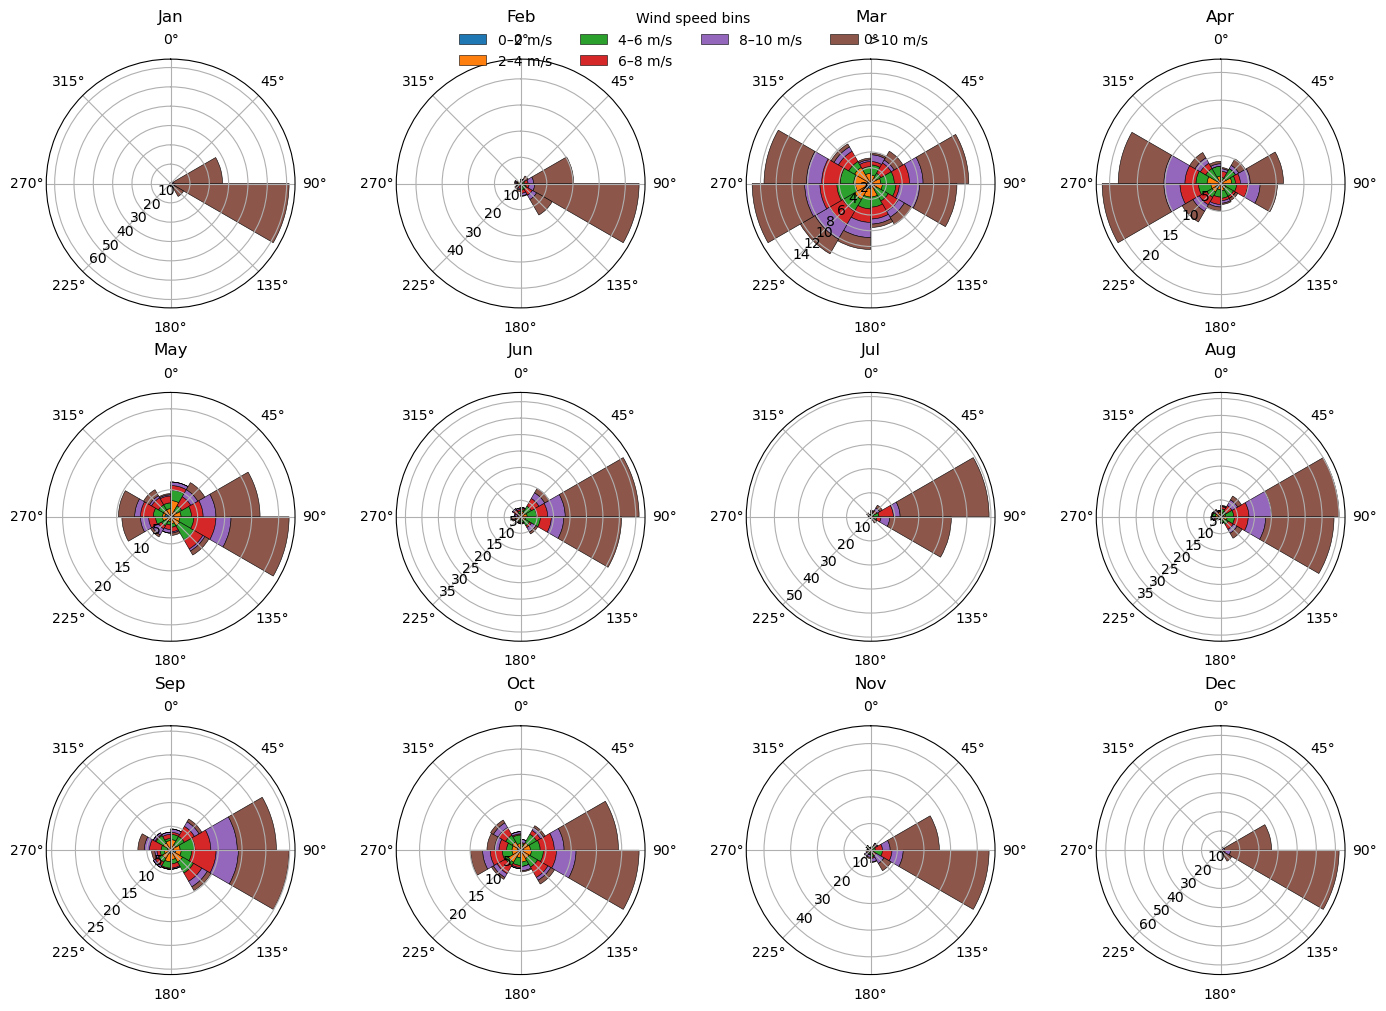

In [38]:
plot_wind_rose_monthly(ws_icon1_da, wd_icon1_da, title="ICON 1000 hPa – Site 1")

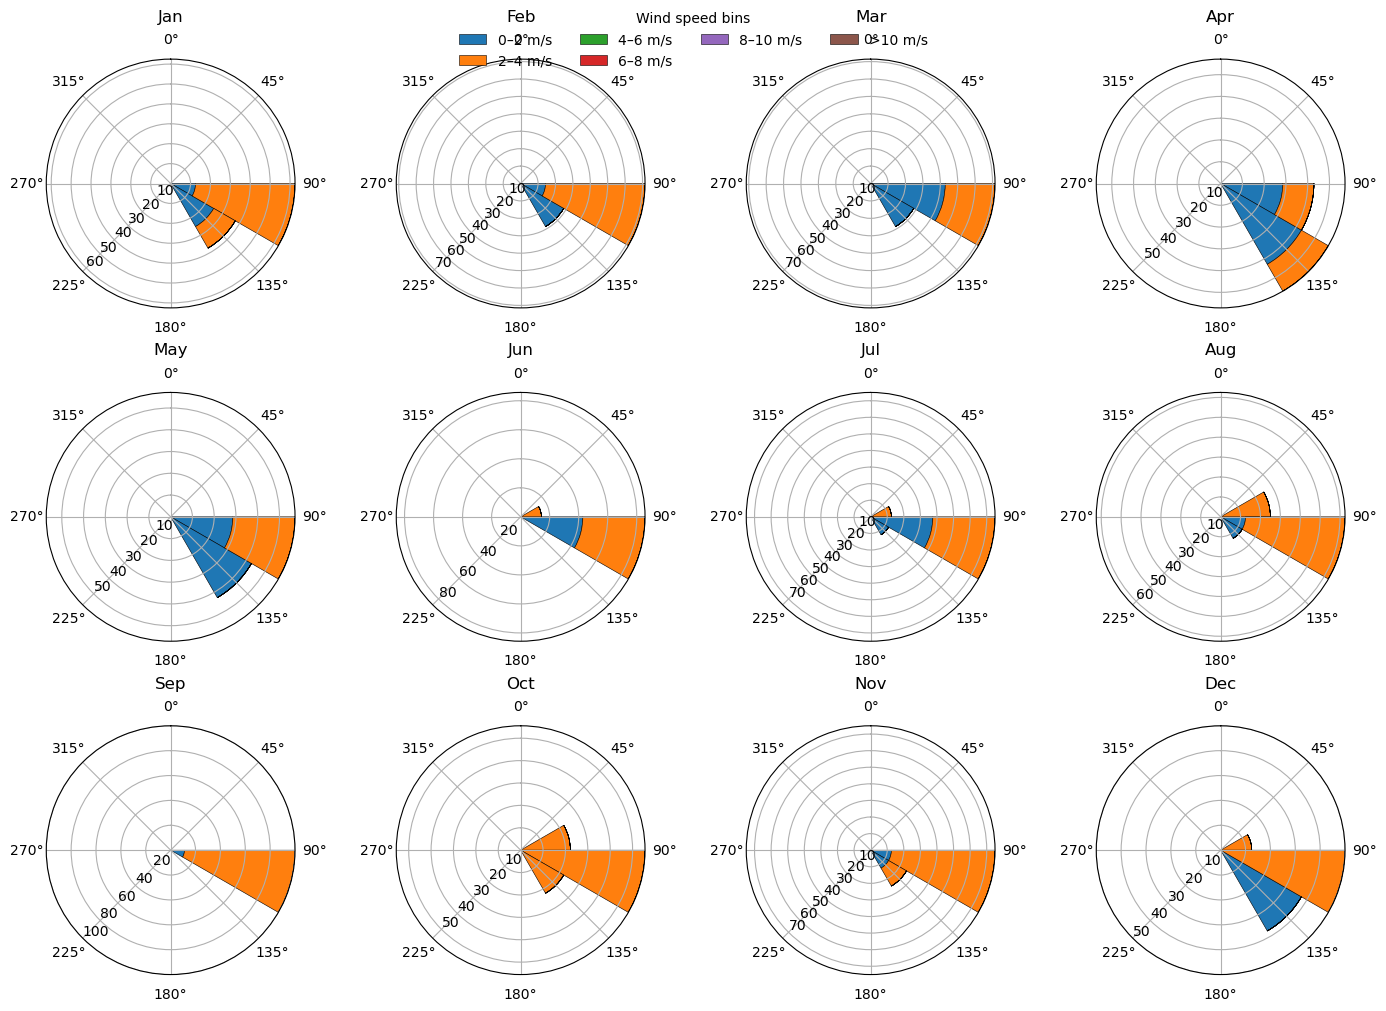

In [39]:
plot_wind_rose_monthly(br_sa1_ws_1d, br_sa1_wd_1d, title="FluxNet – Site 1")

In [51]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Okabe–Ito palette (color-blind friendly)
OKABE_ITO = ["#0072B2","#E69F00","#009E73","#D55E00","#CC79A7","#56B4E9","#F0E442","#999999","#000000"]

def plot_wind_rose_monthly_pair(
    ws1_da, wd1_da, ws2_da, wd2_da,
    label1="Dataset A", label2="Dataset B",
    title="", speed_bins=None, n_dir_sectors=12,
    normalize="percent", min_count=5,
    show_only_used_bins=False
):
    # Align times within each pair
    ws1_da, wd1_da = xr.align(ws1_da, wd1_da, join="inner")
    ws2_da, wd2_da = xr.align(ws2_da, wd2_da, join="inner")

    ds1 = xr.Dataset({"ws": ws1_da, "wd": wd1_da}).sortby("time")
    ds2 = xr.Dataset({"ws": ws2_da, "wd": wd2_da}).sortby("time")

    fig, axes = plt.subplots(3, 4, subplot_kw={"projection": "polar"},
                             figsize=(14, 10), constrained_layout=True)
    axes = axes.ravel()

    # --- bins & labels
    if speed_bins is None:
        speed_bins = [0, 1, 2, 3, 4, 5, 6, np.inf]
    speed_bins = np.asarray(speed_bins, float)
    n_bins = len(speed_bins) - 1
    bin_labels = [f"{speed_bins[i]}–{speed_bins[i+1]} m/s" if np.isfinite(speed_bins[i+1])
                  else f">{speed_bins[i]} m/s" for i in range(n_bins)]
    # Fixed colors per bin (repeat if more bins than palette)
    bin_colors = [OKABE_ITO[i % len(OKABE_ITO)] for i in range(n_bins)]

    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

    # helper to compute counts
    def wind_rose_counts(ws, wd):
        ws = np.asarray(ws, float); wd = np.asarray(wd, float)
        m = np.isfinite(ws) & np.isfinite(wd)
        ws, wd = ws[m], wd[m]
        dir_edges = np.linspace(0, 360, n_dir_sectors + 1)
        dir_idx = np.digitize(wd % 360, dir_edges, right=False) - 1
        dir_idx[dir_idx == n_dir_sectors] = 0
        sp_idx = np.digitize(ws, speed_bins, right=True) - 1
        sp_idx = np.clip(sp_idx, 0, n_bins - 1)
        counts = np.zeros((n_bins, n_dir_sectors), dtype=int)
        for i_s, i_d in zip(sp_idx, dir_idx):
            counts[i_s, i_d] += 1
        centers_deg = (dir_edges[:-1] + dir_edges[1:]) / 2.0
        centers_rad = np.deg2rad(centers_deg)
        return centers_rad, counts

    # Track which bins are actually used (for optional legend pruning)
    used_bins = np.zeros(n_bins, dtype=bool)

    for m in range(1, 13):
        ax = axes[m-1]
        sub1 = ds1.where(ds1.time.dt.month == m, drop=True)
        sub2 = ds2.where(ds2.time.dt.month == m, drop=True)

        if (sub1.time.size < min_count) and (sub2.time.size < min_count):
            ax.set_visible(False)
            continue

        width = 2 * np.pi / n_dir_sectors
        off = 0.25 * width  # side-by-side offset

        def draw_dataset(sub, offset, hatch=None):
            if sub.time.size < min_count:
                return np.zeros(n_bins, dtype=bool)
            ws = sub.ws.values; wd = sub.wd.values
            theta, counts = wind_rose_counts(ws, wd)
            if normalize == "percent" and counts.sum() > 0:
                counts = counts / counts.sum() * 100.0
            bottom = np.zeros(counts.shape[1])
            bins_used_here = np.zeros(n_bins, dtype=bool)
            for ibin in range(n_bins):
                vals = counts[ibin, :]
                if np.any(vals > 0):
                    bins_used_here[ibin] = True
                ax.bar(theta - width/2 + offset, vals,
                       width=0.45*width, bottom=bottom, align="edge",
                       edgecolor="black", linewidth=0.35,
                       facecolor=bin_colors[ibin], hatch=hatch, alpha=1.0)
                bottom += vals
            return bins_used_here

        used_bins |= draw_dataset(sub1, offset=-off, hatch=None)
        used_bins |= draw_dataset(sub2, offset=+off, hatch="///")

        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_title(month_names[m-1], va="bottom")
        ax.set_rlabel_position(225)

    # --- Legends
    # Bin legend (optionally prune to only used bins)
    idxs = np.where(used_bins)[0] if show_only_used_bins else np.arange(n_bins)
    bin_handles = [Patch(facecolor=bin_colors[i], edgecolor="black", linewidth=0.4, label=bin_labels[i])
                   for i in idxs]

    ds_handles = [
        Patch(facecolor="none", edgecolor="black", linewidth=1.0, label=label1),
        Patch(facecolor="none", edgecolor="black", linewidth=1.0, hatch="///", label=label2),
    ]

    fig.legend(handles=bin_handles, loc="upper center", ncol=min(4, len(bin_handles)),
               frameon=False, title="Wind speed bins", bbox_to_anchor=(0.5, 1.14))
    fig.legend(handles=ds_handles, loc="upper center", ncol=2,
               frameon=False, bbox_to_anchor=(0.5, 1.20))

    fig.suptitle(title or "Monthly Wind Rose – Side-by-Side Comparison", y=1.16, fontsize=14)
    plt.show()


In [47]:
ws_icon, wd_icon = uv_to_ws_wd(uas_ctl_sa1.values, vas_ctl_sa1.values)
ws_icon_da1 = xr.DataArray(ws_icon, coords={"time": uas_ctl_sa1["time"]}, dims=["time"])
wd_icon_da1 = xr.DataArray(wd_icon, coords={"time": uas_ctl_sa1["time"]}, dims=["time"])

In [41]:
ws_flux_da1 = br_sa1_ws_1d  # xarray DataArray with time
wd_flux_da1 = br_sa1_wd_1d  # xarray DataArray with time

In [66]:
print(br_sa1_ws_1d.max().item())

2.4950138312586447


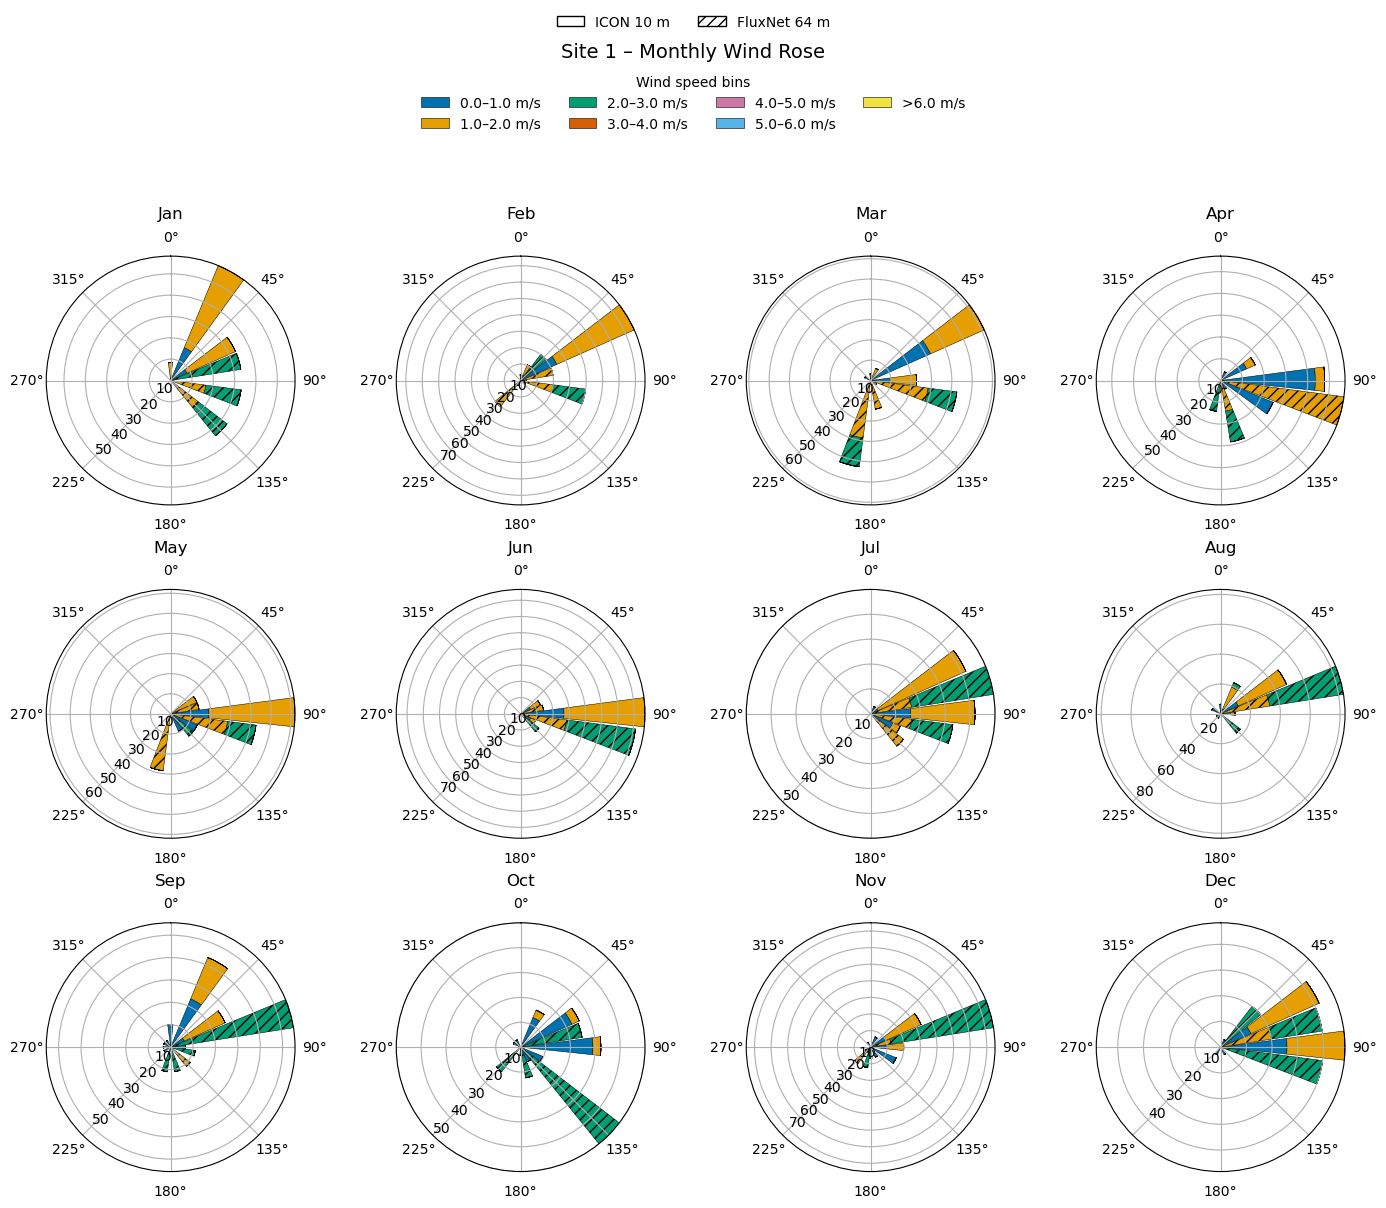

In [54]:
plot_wind_rose_monthly_pair(
    ws_icon_da1, wd_icon_da1,
    ws_flux_da1, wd_flux_da1,
    label1="ICON 10 m", label2="FluxNet 64 m",
    title="Site 1 – Monthly Wind Rose"
)

In [81]:
ws_icon, wd_icon = uv_to_ws_wd(uas_ctl_sa3.values, vas_ctl_sa3.values)
ws_icon_da3 = xr.DataArray(ws_icon, coords={"time": uas_ctl_sa3["time"]}, dims=["time"])
wd_icon_da3 = xr.DataArray(wd_icon, coords={"time": uas_ctl_sa3["time"]}, dims=["time"])

In [82]:
ws_flux_da3 = br_sa3_ws_1d  # xarray DataArray with time
wd_flux_da3 = br_sa3_wd_1d  # xarray DataArray with time

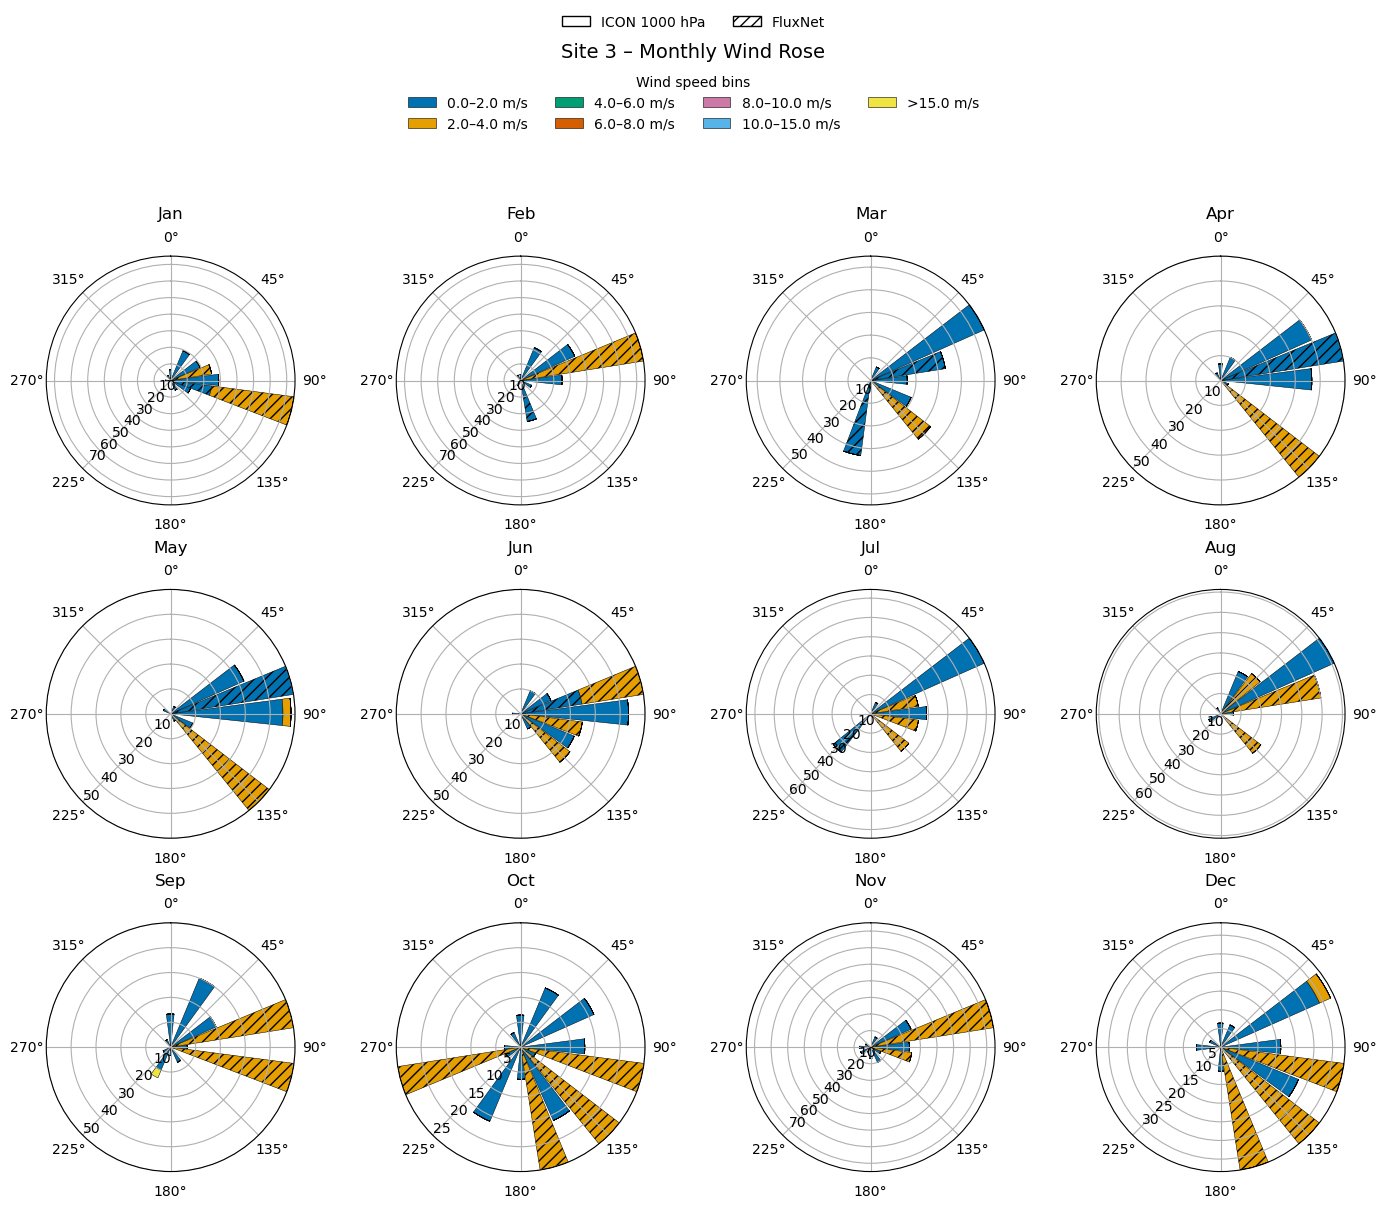

In [71]:
plot_wind_rose_monthly_pair(
    ws_icon_da, wd_icon_da,
    ws_flux_da, wd_flux_da,
    label1="ICON 1000 hPa", label2="FluxNet",
    title="Site 3 – Monthly Wind Rose"
)

In [34]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- helpers ---
def uv_to_ws_wd(u, v):
    """u,v (m/s) -> WS (m/s), WD (deg FROM which wind blows)."""
    ws = np.hypot(u, v)
    wd = (np.degrees(np.arctan2(-u, -v)) + 360.0) % 360.0
    return ws, wd

OKABE_ITO = ["#0072B2","#E69F00","#009E73","#D55E00","#CC79A7",
             "#56B4E9","#F0E442","#999999","#000000"]  # color-blind friendly

def _wind_rose_counts(ws, wd, speed_bins, n_dir_sectors):
    ws = np.asarray(ws, float); wd = np.asarray(wd, float)
    m = np.isfinite(ws) & np.isfinite(wd)
    ws, wd = ws[m], wd[m]

    dir_edges = np.linspace(0, 360, n_dir_sectors + 1)
    dir_idx = np.digitize(wd % 360, dir_edges, right=False) - 1
    dir_idx[dir_idx == n_dir_sectors] = 0

    sp_idx = np.digitize(ws, speed_bins, right=True) - 1
    sp_idx = np.clip(sp_idx, 0, len(speed_bins) - 2)

    counts = np.zeros((len(speed_bins) - 1, n_dir_sectors), dtype=int)
    for i_s, i_d in zip(sp_idx, dir_idx):
        counts[i_s, i_d] += 1

    centers_deg = (dir_edges[:-1] + dir_edges[1:]) / 2.0
    centers_rad = np.deg2rad(centers_deg)
    return centers_rad, counts

def _season_subset(ds, season_label):
    # xarray provides .dt.season with labels 'DJF','MAM','JJA','SON'
    return ds.where(ds.time.dt.season == season_label, drop=True)

# --- main: seasonal wind-rose (single or paired) ---
def plot_wind_rose_seasons(
    ws1_da, wd1_da,
    ws2_da=None, wd2_da=None,
    label1="Dataset A", label2="Dataset B",
    title="Seasonal Wind Rose",
    speed_bins=None, n_dir_sectors=12,
    normalize="percent", min_count=5,
    show_only_used_bins=False
):
    """
    Plot wind roses for DJF, MAM, JJA, SON.
    - If ws2_da/wd2_da are provided, draws side-by-side stacks (dataset 2 with hatching).
    - speed_bins: e.g., [0,2,4,6,8,10,np.inf]
    - normalize: "percent" (each season sums to 100%) or None (raw counts)
    """
    # Align times within each dataset (not across datasets)
    ws1_da, wd1_da = xr.align(ws1_da, wd1_da, join="inner")
    ds1 = xr.Dataset({"ws": ws1_da, "wd": wd1_da}).sortby("time")

    paired = (ws2_da is not None) and (wd2_da is not None)
    if paired:
        ws2_da, wd2_da = xr.align(ws2_da, wd2_da, join="inner")
        ds2 = xr.Dataset({"ws": ws2_da, "wd": wd2_da}).sortby("time")

    # bins & labels
    if speed_bins is None:
        speed_bins = [0, 2, 4, 6, np.inf]
    speed_bins = np.asarray(speed_bins, float)
    n_bins = len(speed_bins) - 1
    bin_labels = [f"{speed_bins[i]}–{speed_bins[i+1]} m/s" if np.isfinite(speed_bins[i+1])
                  else f">{speed_bins[i]} m/s" for i in range(n_bins)]
    bin_colors = [OKABE_ITO[i % len(OKABE_ITO)] for i in range(n_bins)]

    # set up 2x2 polar grid
    fig, axes = plt.subplots(2, 2, subplot_kw={"projection": "polar"},
                             figsize=(11, 9), constrained_layout=True)
    axes = axes.ravel()
    seasons = ["DJF", "MAM", "JJA", "SON"]

    used_bins = np.zeros(n_bins, dtype=bool)

    for ax, s in zip(axes, seasons):
        sub1 = _season_subset(ds1, s)
        sub2 = _season_subset(ds2, s) if paired else None

        if (sub1.time.size < min_count) and (paired and sub2.time.size < min_count):
            ax.set_visible(False)
            continue

        width = 2 * np.pi / n_dir_sectors
        off = 0.25 * width if paired else 0.0  # side-by-side offset only when paired

        def draw_dataset(sub, offset=0.0, hatch=None):
            if sub is None or sub.time.size < min_count:
                return np.zeros(n_bins, dtype=bool)
            ws = sub.ws.values; wd = sub.wd.values
            theta, counts = _wind_rose_counts(ws, wd, speed_bins, n_dir_sectors)
            if normalize == "percent" and counts.sum() > 0:
                counts = counts / counts.sum() * 100.0
            bottom = np.zeros(counts.shape[1])
            bins_used_here = np.zeros(n_bins, dtype=bool)
            for ibin in range(n_bins):
                vals = counts[ibin, :]
                if np.any(vals > 0):
                    bins_used_here[ibin] = True
                ax.bar(theta - width/2 + offset, vals,
                       width=0.45*width if paired else 0.8*width,
                       bottom=bottom, align="edge",
                       edgecolor="black", linewidth=0.35,
                       facecolor=bin_colors[ibin], hatch=hatch, alpha=1.0)
                bottom += vals
            return bins_used_here

        used_bins |= draw_dataset(sub1, offset=-off, hatch=None)
        if paired:
            used_bins |= draw_dataset(sub2, offset=+off, hatch="///")

        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_title(s, va="bottom")
        ax.set_rlabel_position(225)

    # Legends
    idxs = np.where(used_bins)[0] if show_only_used_bins else np.arange(n_bins)
    bin_handles = [Patch(facecolor=bin_colors[i], edgecolor="black", linewidth=0.4, label=bin_labels[i])
                   for i in idxs]
    ds_handles = [Patch(facecolor="none", edgecolor="black", linewidth=1.0, label=label1)]
    if paired:
        ds_handles.append(Patch(facecolor="none", edgecolor="black", linewidth=1.0, hatch="///", label=label2))

    fig.legend(handles=bin_handles, loc="upper center",
               ncol=min(4, len(bin_handles)), frameon=False,
               title="Wind speed bins", bbox_to_anchor=(0.5, 1.08))
    fig.legend(handles=ds_handles, loc="upper center", ncol=len(ds_handles),
               frameon=False, bbox_to_anchor=(0.5, 1.14))

    fig.suptitle(title, y=1.16, fontsize=14)
    plt.show()


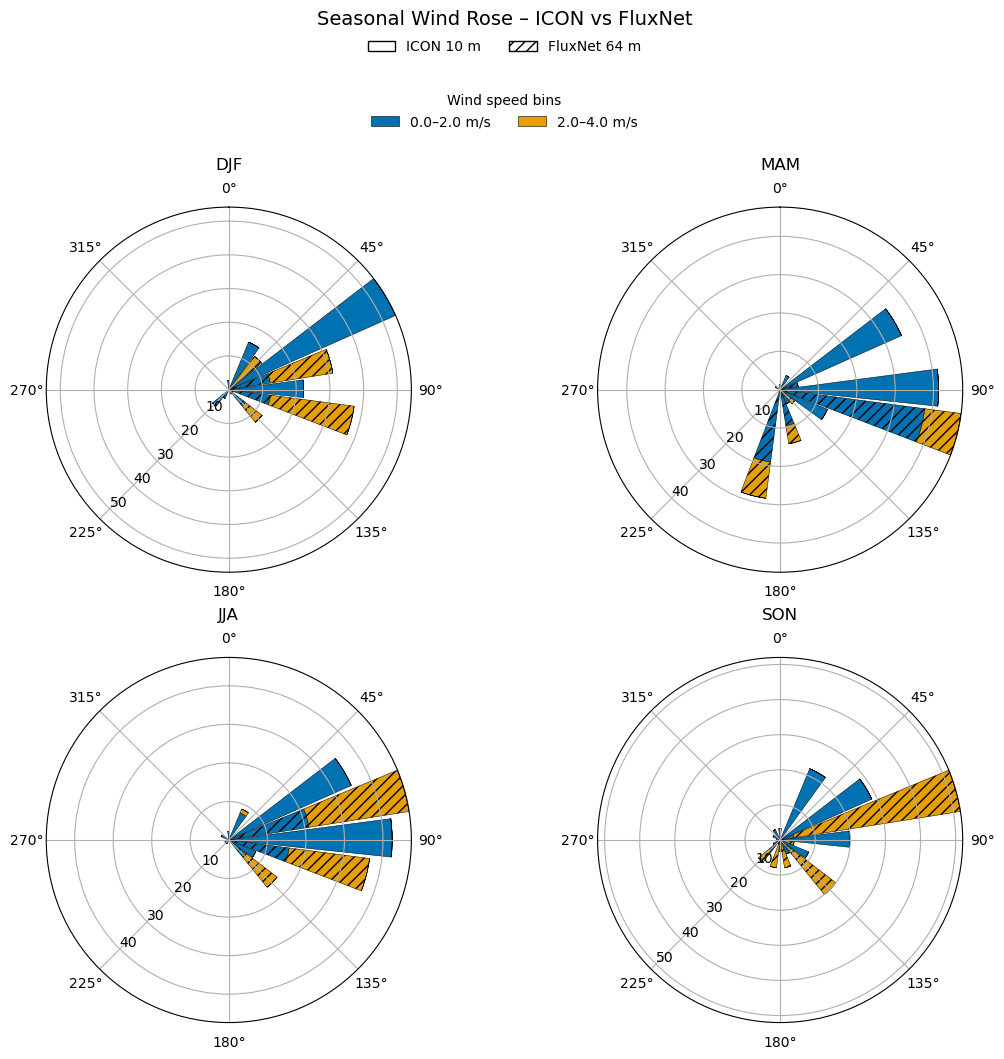

In [57]:
# If you start from ICON u/v:
# ws_icon, wd_icon = uv_to_ws_wd(icon_u_1000_site.values, icon_v_1000_site.values)
# ws_icon_da = xr.DataArray(ws_icon, coords={"time": icon_u_1000_site["time"]}, dims=["time"])
# wd_icon_da = xr.DataArray(wd_icon, coords={"time": icon_u_1000_site["time"]}, dims=["time"])

plot_wind_rose_seasons(
    ws_icon_da1, wd_icon_da1,
    ws2_da=ws_flux_da1, wd2_da=wd_flux_da1,
    label1="ICON 10 m", label2="FluxNet 64 m",
    title="Seasonal Wind Rose – ICON vs FluxNet",
    speed_bins=[0,2,4,np.inf], n_dir_sectors=12, normalize="percent",
    show_only_used_bins=True  # optional: prunes legend to bins that appear
)

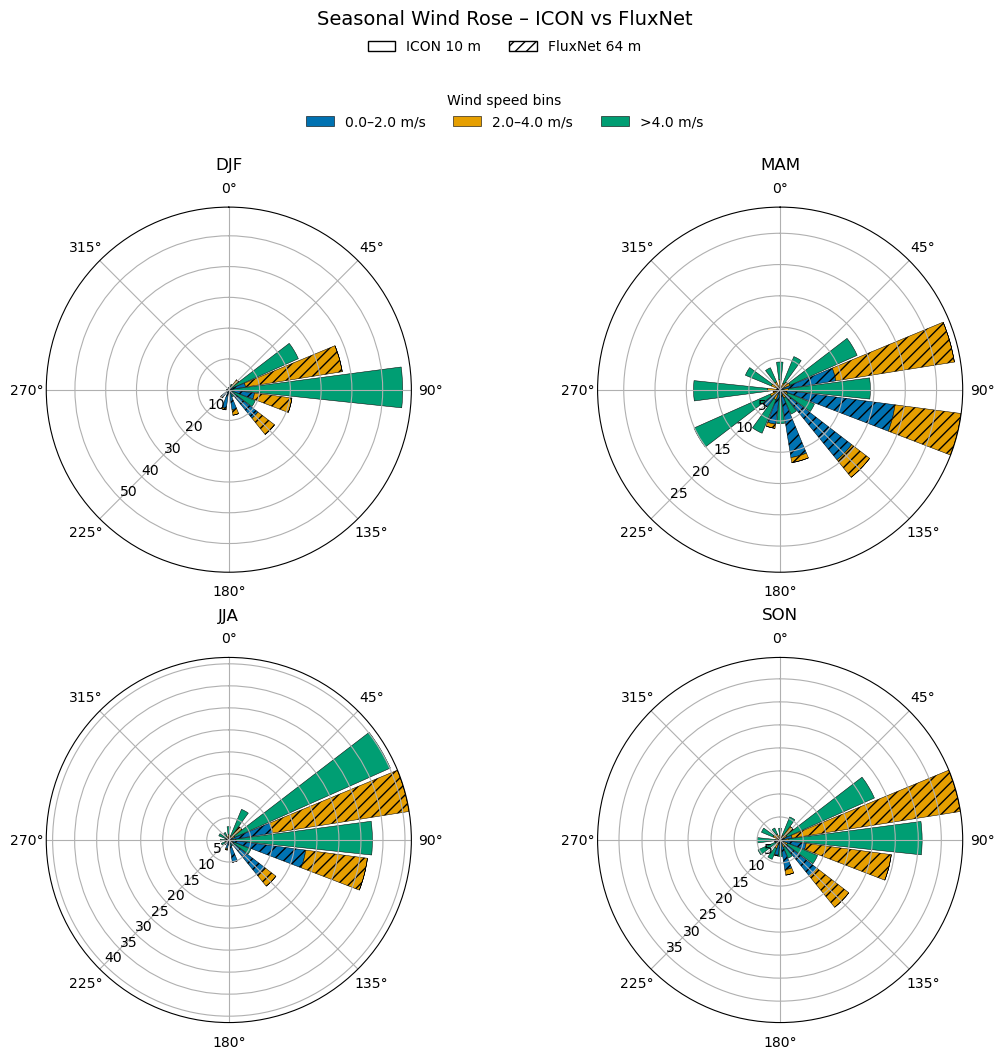

In [42]:
# If you start from ICON u/v:
# ws_icon, wd_icon = uv_to_ws_wd(icon_u_1000_site.values, icon_v_1000_site.values)
# ws_icon_da = xr.DataArray(ws_icon, coords={"time": icon_u_1000_site["time"]}, dims=["time"])
# wd_icon_da = xr.DataArray(wd_icon, coords={"time": icon_u_1000_site["time"]}, dims=["time"])
#ws_icon1_da, wd_icon1_da
plot_wind_rose_seasons(
    ws_icon1_da, wd_icon1_da,
    ws2_da=ws_flux_da1, wd2_da=wd_flux_da1,
    label1="ICON 10 m", label2="FluxNet 64 m",
    title="Seasonal Wind Rose – ICON vs FluxNet",
    speed_bins=[0,2,4,np.inf], n_dir_sectors=12, normalize="percent",
    show_only_used_bins=True  # optional: prunes legend to bins that appear
)

## Ratio - EVP/PR

_1. fluxnet_

In [16]:
# load variables (hourly)
br_sa1_LE = flux_data['LE_F_MDS']
br_sa3_LE = flux_data_sa3['LE_F_MDS']

In [17]:
br_sa1_PR = flux_data['P_ERA']
br_sa3_PR = flux_data_sa3['P_ERA']

In [18]:
# change pandas into xarray (sa3)
br_sa1_le = br_sa1_LE.to_xarray()
br_sa3_le = br_sa3_LE.to_xarray()

In [19]:
br_sa1_pr = br_sa1_PR.to_xarray()
br_sa3_pr = br_sa3_PR.to_xarray()

In [20]:
# sa1 (remove missing values)
br_sa1_le_nonan = br_sa1_le.where(br_sa1_le != -9999.0, np.nan)
br_sa3_le_nonan = br_sa3_le.where(br_sa3_le != -9999.0, np.nan)

In [21]:
# sa1 (remove missing values)
br_sa1_pr_nonan = br_sa1_pr.where(br_sa1_pr != -9999.0, np.nan)
br_sa3_pr_nonan = br_sa3_pr.where(br_sa3_pr != -9999.0, np.nan)

In [22]:
# sa1
br_sa1_le = br_sa1_le_nonan.rename({'TIMESTAMP_START':'time'})
br_sa3_le = br_sa3_le_nonan.rename({'TIMESTAMP_START':'time'})
br_sa1_pr = br_sa1_pr_nonan.rename({'TIMESTAMP_START':'time'})
br_sa3_pr = br_sa3_pr_nonan.rename({'TIMESTAMP_START':'time'})

In [181]:
br_sa1_le

<xarray.DataArray 'LE_F_MDS' (time: 87648)> Size: 701kB
array([71.135 , 70.215 , 58.012 , ..., 22.5898, 22.8944, 23.0913])
Coordinates:
  * time     (time) datetime64[ns] 701kB 2002-01-01 ... 2011-12-31T23:00:00

_2. Load icon data_

In [15]:
#Define a global pattern to find the files
glob_pattern_pr = 'ctl_hourly_pr_202'
glob_pattern_hfls = 'ctl_hourly_hfls_202'

## Define the paths
data_path_pr = Path('/scratch/m/m300948/test_04/pr')
data_path_hfls = Path('/scratch/m/m300948/test_04/hfls')

## Collect all file names with pathlib's rglob and list compression  
file_icon_pr = sorted([str(f) for f in data_path_pr.rglob(f'*{glob_pattern_pr}?.nc')])[:]
file_icon_hfls = sorted([str(f) for f in data_path_hfls.rglob(f'*{glob_pattern_hfls}?.nc')])[:]

In [ ]:
times = ['2020-01-01','2022-12-31']
pr_ctl_land = Tools.time_mean_model(file_icon_pr,times,'1D','pr',[-30,13],[-82,-30],'land')

In [ ]:
times = ['2020-01-01','2022-12-31']
hfls_ctl_land = Tools.time_mean_model(file_icon_hfls,times,'1D','hfls',[-30,13],[-82,-30],'land')

In [17]:
pr_icon = xr.open_mfdataset(file_icon_pr)['pr']

In [18]:
hfls_icon = xr.open_mfdataset(file_icon_hfls)['hfls']

In [19]:
AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome = AMZ_BD.interp(latitude=pr_icon.lat, longitude=pr_icon.lon)

pr_ctl_mask = pr_icon.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
hfls_ctl_mask = hfls_icon.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

pr_ctl_land = pr_ctl_mask.resample(time='D').mean()
hfls_ctl_land = hfls_ctl_mask.resample(time='D').mean()

_a. interpolation one point_

In [30]:
pr_ctl_sa1 = pr_ctl_land.interp(lat=-2.8567, lon=-54.9589, method='nearest')
hfls_ctl_sa1 = hfls_ctl_land.interp(lat=-2.8567, lon=-54.9589, method='nearest')

pr_ctl_sa3 = pr_ctl_land.interp(lat=-3.0180, lon=-54.9714, method='nearest')
hfls_ctl_sa3 = hfls_ctl_land.interp(lat=-3.0180, lon=-54.9714, method='nearest')

_b. average over the area_

In [25]:
# fluxnet (lat: -2.8567, lon: -54.9589)
dist_degree = 1.0 # 0.1 degree = 11.1 km

hfls_ctl_subset_sa1 = hfls_ctl_land.sel(lat=slice(-2.8567-dist_degree,-2.8567+dist_degree), lon=slice(-54.9589-dist_degree,-54.9589+dist_degree)).mean(('lat','lon'))
pr_ctl_subset_sa1 = pr_ctl_land.sel(lat=slice(-2.8567-dist_degree,-2.8567+dist_degree), lon=slice(-54.9589-dist_degree,-54.9589+dist_degree)).mean(('lat','lon'))

NameError: name 'hfls_ctl_land' is not defined

In [21]:
# fluxnet (lat: -3.0180, lon: -54.9714)
dist_degree = 0.5 # 0.1 degree = 11.1 km

hfls_ctl_subset_sa3 = hfls_ctl_land.sel(lat=slice(-3.0180-dist_degree,-3.0180+dist_degree), lon=slice(-54.9714-dist_degree,-54.9714+dist_degree)).mean(('lat','lon'))
pr_ctl_subset_sa3 = pr_ctl_land.sel(lat=slice(-3.0180-dist_degree,-3.0180+dist_degree), lon=slice(-54.9714-dist_degree,-54.9714+dist_degree)).mean(('lat','lon'))

### Monthly mean

In [23]:
# Fluxnet
br_sa1_lh_month = br_sa1_le.groupby('time.month').mean('time')
br_sa3_lh_month = br_sa3_le.groupby('time.month').mean('time')

br_sa1_pr_month = br_sa1_pr.groupby('time.month').mean('time')
br_sa3_pr_month = br_sa3_pr.groupby('time.month').mean('time')

In [24]:
br_lh_month = (br_sa3_lh_month + br_sa1_lh_month)/2 /28.94
br_pr_month = (br_sa3_pr_month + br_sa1_pr_month)/2 * 24

In [ ]:
# ICON
pr_ctl_sa1_month = pr_ctl_subset_sa1.groupby('time.month').mean('time') * 3600 * 24
pr_ctl_sa3_month = pr_ctl_subset_sa3.groupby('time.month').mean('time') * 3600 * 24

In [25]:
hfls_ctl_sa1_month = hfls_ctl_subset_sa1.groupby('time.month').mean('time') 
hfls_ctl_sa3_month = hfls_ctl_subset_sa3.groupby('time.month').mean('time') 

In [26]:
hfls_ctl_month = (hfls_ctl_sa1_month + hfls_ctl_sa3_month)/2 / 28.94 # wm-2
pr_ctl_month = (pr_ctl_sa1_month + pr_ctl_sa3_month)/2  # mm/day

In [25]:
print(br_lh_month.values)
print(br_pr_month.values)

[3.01013312 2.92570774 2.90282656 2.8475224  2.86282099 3.04351576
 3.24511253 3.48868448 3.51923422 3.43518011 3.20431375 3.05142683]
[5.25803871 6.83427662 6.68709032 7.18894333 5.77530645 4.593395
 3.74824677 3.14245645 3.00330167 2.49342258 3.24955167 4.37383226]


In [26]:
import numpy as np
#hfls_ctl_month = np.array([-4.329718 , -4.393611 , -4.4474235, -4.3475585, -4.3081946,
#       -4.2311068, -4.353479 , -4.216062 , -4.7997317, -4.5066724,
#       -4.5268884, -4.1679196])
#pr_ctl_month = np.array([8.3288555, 8.723    , 9.2186775, 7.759737 , 6.1799293, 4.1165752,
#       2.0269933, 4.0157623, 5.0083447, 8.833532 , 6.2114506, 7.568426 ])

#hfls_ctl_month = np.array([-4.343059,  -4.4835196, -4.5067177, -4.3936706, -4.258304,  -4.1977916,
# -4.526769,  -4.5324254, -4.794309,  -4.6121845, -4.5658274, -4.1816163])
#pr_ctl_month = np.array([7.9585657, 7.7785397, 9.139378,  7.78928,   7.2694316, 5.811032,  2.5667164,
# 3.7022653, 5.031837,  8.7460165, 6.3657217, 7.696312 ])

hfls_ctl_month = np.array([-4.375957,  -4.5480323, -4.580853,  -4.430154,  -4.2425504, -4.1973047,
 -4.513094,  -4.5252886 ,-4.762926 , -4.6303687, -4.5979285 ,-4.212014 ])

pr_ctl_month = np.array([8.211904 , 8.063404,  9.817481 , 8.461283 , 7.689181 , 5.697048 , 2.7155948,
 3.647253,  5.016267,  8.898502 , 6.976425,  8.487391 ])

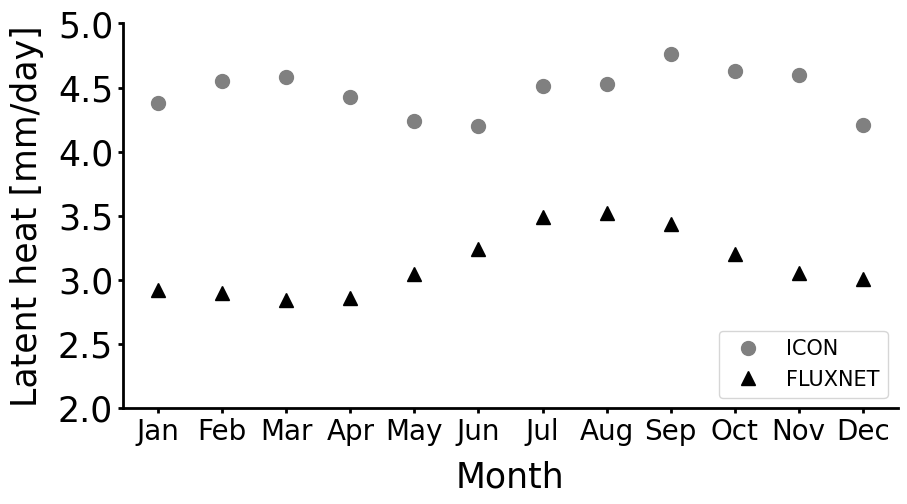

In [27]:
br_lh_month_shifted = br_lh_month.roll(month=-1)
#imerg_pr_amz_savg_std_shifted = imerg_pr_amz_savg_std.roll(month=-1)

# Example plot
months = np.arange(1, 13)  # Exclude the first month for mean plot

fig, ax = plt.subplots(figsize=(10, 5))
#plt.errorbar(months, br_sh_mean[:], yerr=br_sh_std[:], fmt='o', color='black', ecolor='grey', capsize=10,  markersize='10')
plt.errorbar(months, -hfls_ctl_month[:], fmt='o', label='ICON', color='grey', capsize=10,  markersize='10')
plt.errorbar(months, br_lh_month_shifted[:], fmt='^', label='FLUXNET',color='black', capsize=10,  markersize='10')
#plt.ylabel('Temperature (K)')
#plt.title('Mean Precipitation with Standard Deviation')

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(np.linspace(1,12,12),months,fontsize=20)
plt.yticks(fontsize=25)
plt.ylim(2, 5)

ax.set_ylabel('Latent heat [mm/day]',fontsize=25, labelpad = 10)
ax.set_xlabel('Month',fontsize=25, labelpad = 10)

ax.xaxis.set_tick_params(width=2)
ax.yaxis.set_tick_params(width=2)

# The spines
plt.setp(ax.spines.values(), linewidth=2)

#plt.grid(True)
ax.spines[['right', 'top']].set_visible(False)
plt.legend(loc='lower right', fontsize=15)
plt.show()

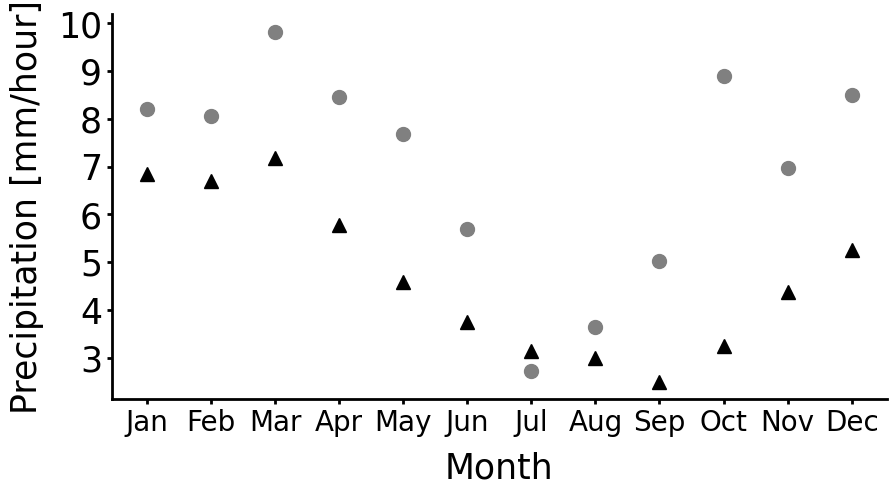

In [28]:
br_pr_month_shifted = br_pr_month.roll(month=-1)
#imerg_pr_amz_savg_std_shifted = imerg_pr_amz_savg_std.roll(month=-1)

# Example plot
months = np.arange(1, 13)  # Exclude the first month for mean plot

fig, ax = plt.subplots(figsize=(10, 5))
#plt.errorbar(months, br_sh_mean[:], yerr=br_sh_std[:], fmt='o', color='black', ecolor='grey', capsize=10,  markersize='10')
plt.errorbar(months, pr_ctl_month[:], fmt='o', label='ICON', color='grey', capsize=10,  markersize='10')
plt.errorbar(months, br_pr_month_shifted[:], fmt='^', label='FLUXNET', color='black', capsize=10,  markersize='10')
#plt.ylabel('Temperature (K)')
#plt.title('Mean Precipitation with Standard Deviation')

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(np.linspace(1,12,12),months,fontsize=20)
plt.yticks(fontsize=25)
#plt.ylim(0, 50)

ax.set_ylabel('Precipitation [mm/hour]',fontsize=25, labelpad = 10)
ax.set_xlabel('Month',fontsize=25, labelpad = 10)

ax.xaxis.set_tick_params(width=2)
ax.yaxis.set_tick_params(width=2)

# The spines
plt.setp(ax.spines.values(), linewidth=2)

#plt.grid(True)
ax.spines[['right', 'top']].set_visible(False)
plt.show()

In [29]:
ratio_icon = -hfls_ctl_month/ pr_ctl_month
ratio_tower = br_lh_month_shifted/br_pr_month_shifted

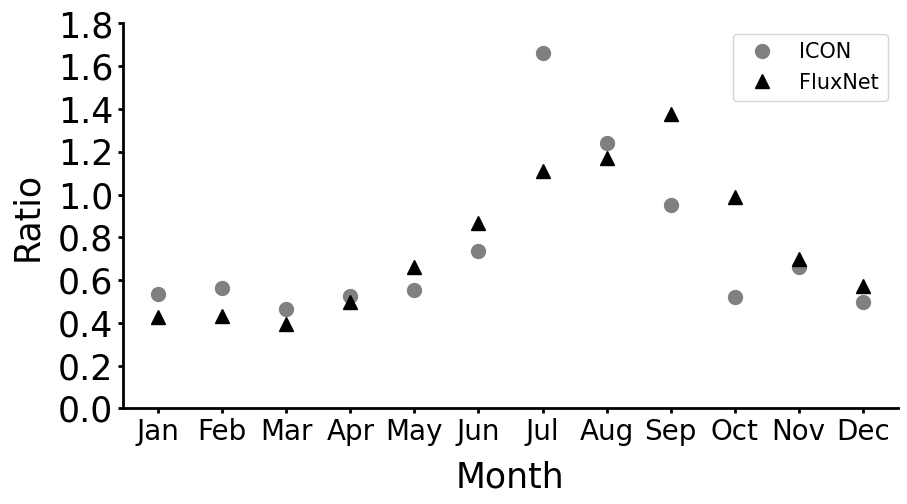

In [34]:
ratio_tower_shifted = ratio_tower #ratio_tower.roll(month=-1)
#imerg_pr_amz_savg_std_shifted = imerg_pr_amz_savg_std.roll(month=-1)

# Example plot
months = np.arange(1, 13)  # Exclude the first month for mean plot

fig, ax = plt.subplots(figsize=(10, 5))
#plt.errorbar(months, br_sh_mean[:], yerr=br_sh_std[:], fmt='o', color='black', ecolor='grey', capsize=10,  markersize='10')
plt.errorbar(months, ratio_icon[:], fmt='o', color='gray', capsize=10,  markersize='10', label='ICON')
plt.errorbar(months, ratio_tower_shifted[:], fmt='^', color='black', capsize=10,  markersize='10', label='FluxNet')
#plt.ylabel('Temperature (K)')
#plt.title('Mean Precipitation with Standard Deviation')

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(np.linspace(1,12,12),months,fontsize=20)
plt.yticks(fontsize=25)
plt.ylim(0.0, 1.8)

ax.set_ylabel('Ratio',fontsize=25, labelpad = 10)
ax.set_xlabel('Month',fontsize=25, labelpad = 10)

ax.xaxis.set_tick_params(width=2)
ax.yaxis.set_tick_params(width=2)

# The spines
plt.setp(ax.spines.values(), linewidth=2)

#plt.grid(True)
ax.spines[['right', 'top']].set_visible(False)
plt.legend(fontsize=15)
plt.show()